# Exploratory Data Analysis (EDA)

This notebook explores the Panama electricity load dataset.
The goal is to understand temporal patterns, seasonality,
and key characteristics of the target variable before modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [7]:
data_path = "data/raw/continuous_dataset.csv"
df = pd.read_csv(data_path)
df.head()


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [8]:
df.shape

(48048, 17)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB


In [10]:
df.columns

Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school'],
      dtype='object')

In [11]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

df.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [12]:
target = 'nat_demand'

In [13]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
nat_demand,0
T2M_toc,0
QV2M_toc,0
TQL_toc,0
W2M_toc,0
T2M_san,0
QV2M_san,0
TQL_san,0
W2M_san,0
T2M_dav,0


## Daily / Weekly Patterns

Electricity load typically shows strong daily and weekly seasonality.
We create time-based features (hour, weekday) for analysis.
# 1. Create time-based features from datetime index

In [14]:
# 1. Create time-based features from datetime index
df["hour"] = df.index.hour
df["weekday"] = df.index.weekday  # 0=Mon, 6=Sun
df["month"] = df.index.month


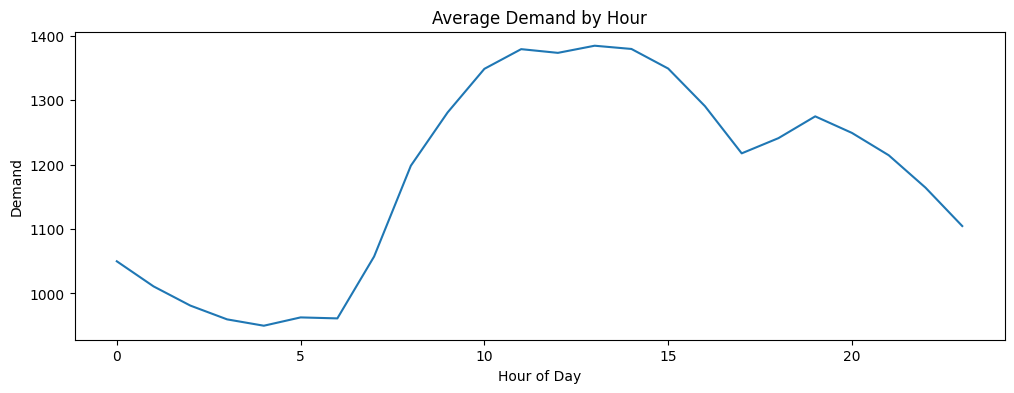

In [15]:
# 2. Average demand by hour (daily pattern)
plt.figure(figsize=(12, 4))
df.groupby("hour")[target].mean().plot()
plt.title("Average Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Demand")
plt.show()



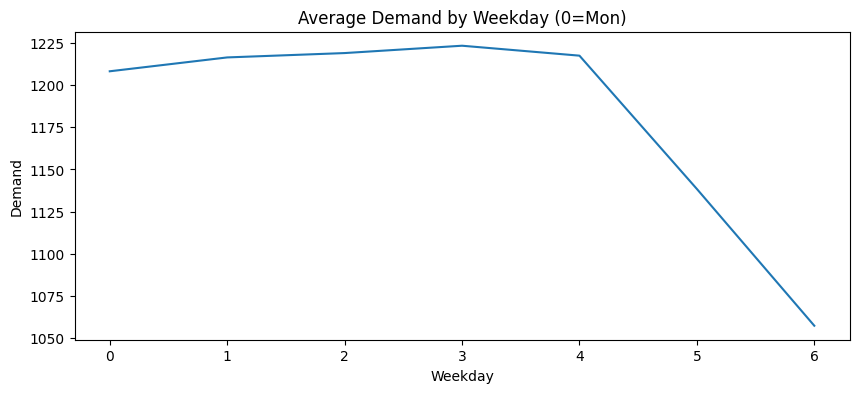

In [16]:
# 3. Average demand by weekday (weekly pattern)
plt.figure(figsize=(10, 4))
df.groupby("weekday")[target].mean().plot()
plt.title("Average Demand by Weekday (0=Mon)")
plt.xlabel("Weekday")
plt.ylabel("Demand")
plt.show()


## Relationship with Weather Features

check correlation between demand and weather variables.
This helps motivate using exogenous variables in forecasting models.


In [17]:
# 1. Correlation of all numeric features with the target
corr_with_target = df.corr(numeric_only=True)[target].sort_values(ascending=False)

# 2. Show top positive/negative correlations
corr_with_target.head(15), corr_with_target.tail(15)


(nat_demand    1.000000
 T2M_toc       0.652811
 T2M_dav       0.648279
 T2M_san       0.627024
 hour          0.453087
 W2M_san       0.191796
 TQL_san       0.119038
 W2M_toc       0.098435
 TQL_toc       0.073109
 TQL_dav       0.042037
 school        0.040044
 QV2M_san      0.022172
 month         0.006412
 QV2M_dav     -0.002117
 QV2M_toc     -0.036706
 Name: nat_demand, dtype: float64,
 hour          0.453087
 W2M_san       0.191796
 TQL_san       0.119038
 W2M_toc       0.098435
 TQL_toc       0.073109
 TQL_dav       0.042037
 school        0.040044
 QV2M_san      0.022172
 month         0.006412
 QV2M_dav     -0.002117
 QV2M_toc     -0.036706
 W2M_dav      -0.054802
 Holiday_ID   -0.129834
 holiday      -0.165673
 weekday      -0.226683
 Name: nat_demand, dtype: float64)

## Correlation Analysis (Heatmap)

Before building forecasting models, we examine the correlation
between electricity demand and other numerical variables.

This analysis helps:
- Identify variables strongly related to the target
- Detect redundant or highly correlated features
- Motivate feature selection and model design choices


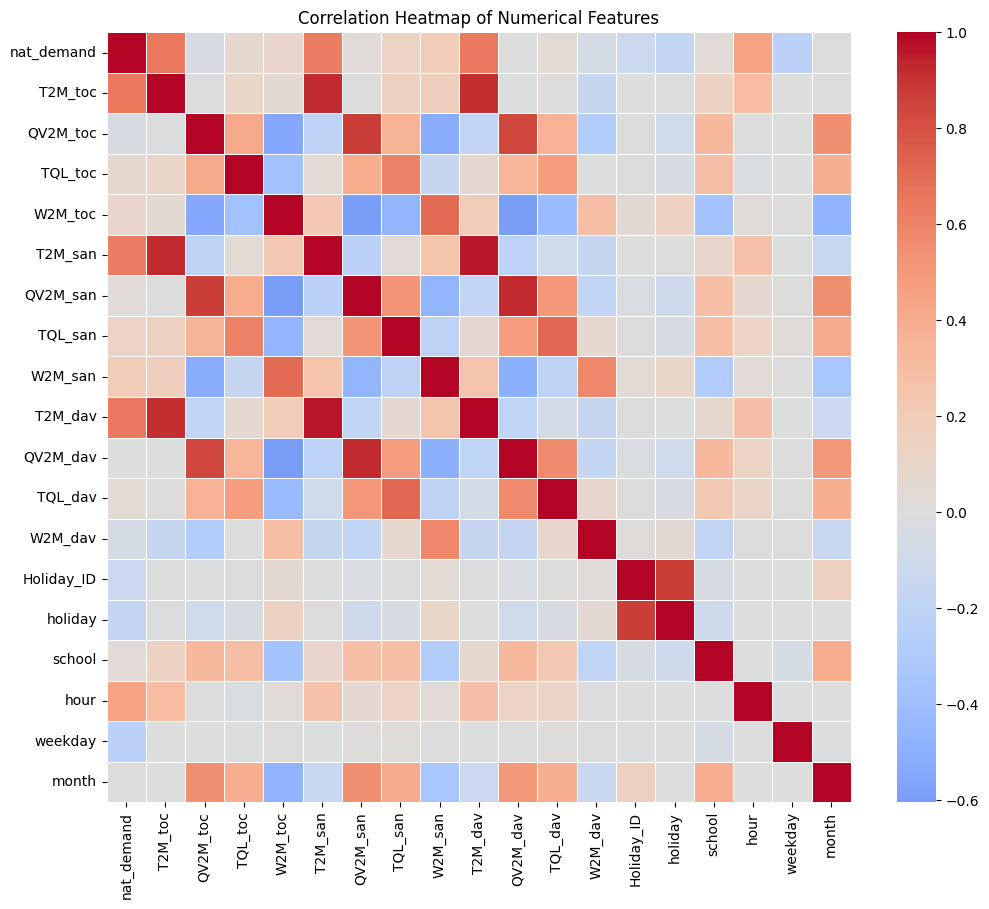

In [18]:
# Compute correlation matrix for numerical features only
corr_matrix = df.corr(numeric_only=True)

# Visualize correlation structure using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()


### Target Variable Distribution

This section examines the distribution of electricity demand to:
- Understand the overall shape of the target variable
- Identify potential skewness and outliers
- Assess whether normalization or scaling may be required before modeling


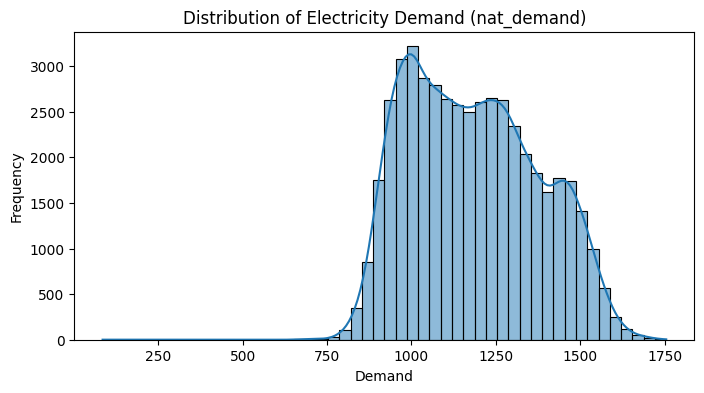

In [23]:


plt.figure(figsize=(8, 4))
sns.histplot(df[target], bins=50, kde=True)
plt.title("Distribution of Electricity Demand (nat_demand)")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()


### Time Series of Electricity Demand

This section visualizes the electricity demand time series to:
- Inspect long-term trends
- Identify seasonal patterns
- Understand overall temporal variability, which informs model selection


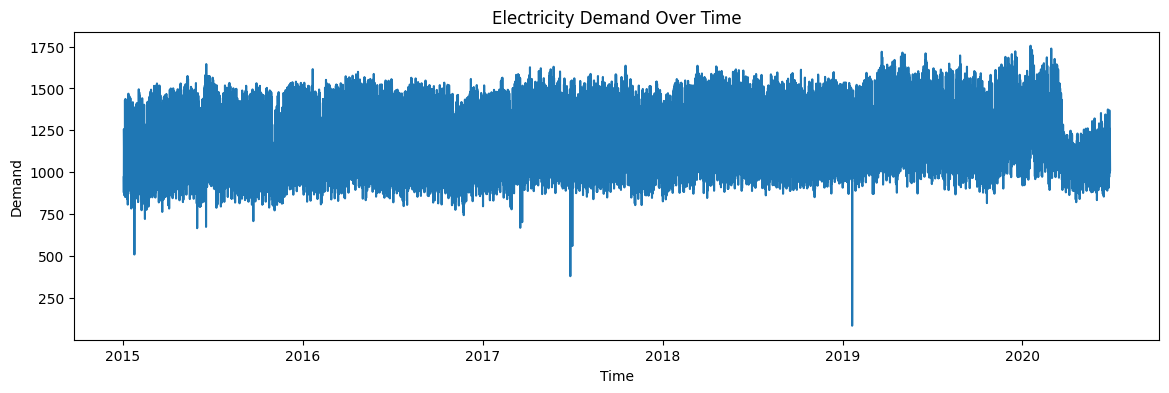

In [24]:

plt.figure(figsize=(14, 4))
plt.plot(df.index, df[target])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.show()


## EDA Summary

Through exploratory data analysis (EDA), we identify the following key characteristics of the electricity demand data:

- Electricity demand (`net_demand`) exhibits a clear daily cycle driven by the hour of the day, with peak demand occurring during daytime hours and lower demand during nighttime.
- Average demand varies by weekday, indicating distinct demand patterns between weekdays and weekends. This suggests the presence of weekly seasonality in the electricity demand time series.
- Weather-related features from the T2M dataset show strong positive correlations with electricity demand, indicating that temperature is an important variable for demand forecasting.
- Some weather features exhibit high inter-feature correlations, suggesting potential redundancy. Feature selection or regularization techniques may therefore be necessary in subsequent modeling stages.

Based on these findings, electricity demand forecasting can be framed as a time series problem with strong temporal dependencies and seasonal patterns. In the next stage, the data will be transformed into fixed-length time windows, and sequence-based deep learning models such as LSTM and 1D CNN will be applied.
